In [2]:
!pip install numpy pandas matplotlib seaborn scipy scikit-learn openpyxl

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

Starting assignment...

A1: Purchase Data
Vectors: 10
Dimensions: 3
Rank: 3
Candy cost: 0.9999999999999949
Mango cost: 55.000000000000014
Milk cost: 18.0

A2: Customer Classification
Rich: 6
Poor: 4

A3: Stock Analysis
Mean price: 1560.6634538152612
Var price: 58496.49239931613
My mean: 1560.6634538152612
My var: 58732.365352539186
NP time avg: 1.1706352233886719e-05
My time avg: 8.559226989746093e-06
Wed mean: 1550.7060000000001
Apr mean: 1698.9526315789474
Loss prob: 0.4979919678714859
Wed profit prob: 0.42


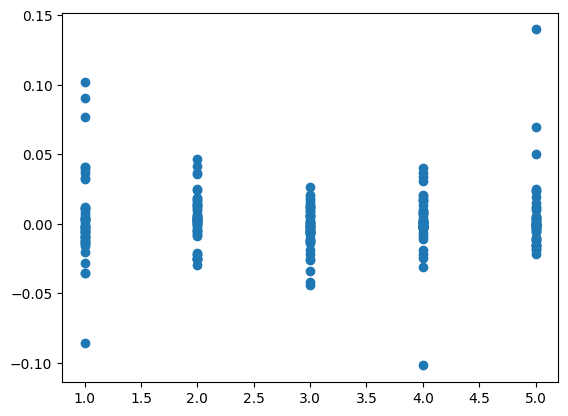


A4: Thyroid Data
Rows: 9172
Cols: 31
Record ID missing: 0
Record ID mean: 852947346.6122983
Record ID std: 7581968.7803465845
age missing: 0
age mean: 73.55582206716092
age std: 1183.976718044466
sex missing: 0
on thyroxine missing: 0
query on thyroxine missing: 0
on antithyroid medication missing: 0
sick missing: 0
pregnant missing: 0
thyroid surgery missing: 0
I131 treatment missing: 0
query hypothyroid missing: 0
query hyperthyroid missing: 0
lithium missing: 0
goitre missing: 0
tumor missing: 0
hypopituitary missing: 0
psych missing: 0
TSH measured missing: 0
TSH missing: 0
T3 measured missing: 0
T3 missing: 0
TT4 measured missing: 0
TT4 missing: 0
T4U measured missing: 0
T4U missing: 0
FTI measured missing: 0
FTI missing: 0
TBG measured missing: 0
TBG missing: 0
referral source missing: 0
Condition missing: 0

A5: Similarity
JC: 0
SMC: 0

A6: Cosine
Cosine: 0.9999999999999998

A7: Heatmap


TypeError: can't multiply sequence by non-int of type 'str'

In [14]:
# Main function to run everything
def main():
    print("Starting assignment...")
    
    # A1 - Purchase Data
    print("\nA1: Purchase Data")
    df1 = pd.read_excel('Data/Lab Session Data.xlsx', sheet_name='Purchase data')
    
    X = df1[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values
    y = df1['Payment (Rs)'].values
    
    print("Vectors:", len(X))
    print("Dimensions:", X.shape[1])
    print("Rank:", np.linalg.matrix_rank(X))
    
    pinv_X = np.linalg.pinv(X)
    costs = pinv_X @ y.reshape(-1, 1)
    print("Candy cost:", costs[0][0])
    print("Mango cost:", costs[1][0])
    print("Milk cost:", costs[2][0])
    
    # A2 - Classify customers
    print("\nA2: Customer Classification")
    df1['Class'] = ['RICH' if x > 200 else 'POOR' for x in df1['Payment (Rs)']]
    print("Rich:", sum(df1['Class'] == 'RICH'))
    print("Poor:", sum(df1['Class'] == 'POOR'))
    
    # A3 - Stock Data
    print("\nA3: Stock Analysis")
    df2 = pd.read_excel('Data/Lab Session Data.xlsx', sheet_name='IRCTC Stock Price')
    
    price = df2['Price'].dropna()
    print("Mean price:", np.mean(price))
    print("Var price:", np.var(price))
    
    # Custom mean function
    def my_mean(arr):
        return sum(arr) / len(arr)
    
    # Custom var function
    def my_var(arr):
        m = my_mean(arr)
        return sum((x - m)**2 for x in arr) / (len(arr) - 1)
    
    print("My mean:", my_mean(price))
    print("My var:", my_var(price))
    
    # Time test
    times_np = []
    times_my = []
    for _ in range(10):
        start = time.time()
        np.mean(price)
        times_np.append(time.time() - start)
        
        start = time.time()
        my_mean(price)
        times_my.append(time.time() - start)
    
    print("NP time avg:", np.mean(times_np))
    print("My time avg:", np.mean(times_my))
    
    # Wednesday and April
    df2['Date'] = pd.to_datetime(df2['Date'])
    df2['Day'] = df2['Date'].dt.day_name()
    df2['Month'] = df2['Date'].dt.month_name()
    
    wed = df2[df2['Day'] == 'Wednesday']['Price']
    apr = df2[df2['Month'] == 'April']['Price']
    
    if len(wed) > 0:
        print("Wed mean:", np.mean(wed))
    if len(apr) > 0:
        print("Apr mean:", np.mean(apr))
    
    # Probability
    chg = df2['Chg%'].dropna()
    loss_prob = sum(1 for x in chg if x < 0) / len(chg)
    print("Loss prob:", loss_prob)
    
    wed_chg = df2[df2['Day'] == 'Wednesday']['Chg%'].dropna()
    if len(wed_chg) > 0:
        wed_profit = sum(1 for x in wed_chg if x > 0) / len(wed_chg)
        print("Wed profit prob:", wed_profit)
    
    # Plot
    day_num = {'Monday':1, 'Tuesday':2, 'Wednesday':3, 'Thursday':4, 
               'Friday':5, 'Saturday':6, 'Sunday':7}
    df2['DayNum'] = df2['Day'].map(day_num)
    
    plt.scatter(df2['DayNum'], df2['Chg%'])
    plt.show()
    
    # A4 - Thyroid data
    print("\nA4: Thyroid Data")
    df3 = pd.read_excel('Data/Lab Session Data.xlsx', sheet_name='thyroid0387_UCI')
    
    print("Rows:", df3.shape[0])
    print("Cols:", df3.shape[1])
    
    for col in df3.columns:
        miss = df3[col].isnull().sum()
        print(col, "missing:", miss)
        
        if df3[col].dtype in ['int64', 'float64']:
            print(col, "mean:", df3[col].mean())
            print(col, "std:", df3[col].std())
    
    # A5 - Similarity
    print("\nA5: Similarity")
    row1 = df3.iloc[0]
    row2 = df3.iloc[1]
    
    binary_cols = []
    for col in df3.columns:
        vals = df3[col].dropna().unique()
        if set(vals).issubset({0,1}):
            binary_cols.append(col)
    
    v1 = []
    v2 = []
    for col in binary_cols:
        v1.append(0 if pd.isna(row1[col]) else row1[col])
        v2.append(0 if pd.isna(row2[col]) else row2[col])
    
    f11 = sum(1 for i in range(len(v1)) if v1[i]==1 and v2[i]==1)
    f00 = sum(1 for i in range(len(v1)) if v1[i]==0 and v2[i]==0)
    f10 = sum(1 for i in range(len(v1)) if v1[i]==1 and v2[i]==0)
    f01 = sum(1 for i in range(len(v1)) if v1[i]==0 and v2[i]==1)
    
    JC = f11 / (f01 + f10 + f11) if (f01+f10+f11)>0 else 0
    SMC = (f11+f00) / (f00+f01+f10+f11) if (f00+f01+f10+f11)>0 else 0
    
    print("JC:", JC)
    print("SMC:", SMC)
    
    # A6 - Cosine
    print("\nA6: Cosine")

    # Select ONLY numeric columns
    numeric_cols = df3.select_dtypes(include=['int64', 'float64']).columns

    row1_num = df3.loc[0, numeric_cols].values
    row2_num = df3.loc[1, numeric_cols].values

    v1_all = np.nan_to_num(row1_num, nan=0)
    v2_all = np.nan_to_num(row2_num, nan=0)

    dot = np.dot(v1_all, v2_all)
    norm1 = np.sqrt(np.sum(v1_all**2))
    norm2 = np.sqrt(np.sum(v2_all**2))

    cos = dot / (norm1 * norm2) if norm1 > 0 and norm2 > 0 else 0
    print("Cosine:", cos)

    
    # A7 - Heatmap
    print("\nA7: Heatmap")
    data_20 = df3.head(20).values
    data_20 = np.nan_to_num(data_20, nan=0)
    
    n = len(data_20)
    sim_matrix = np.zeros((n,n))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                sim_matrix[i,j] = 1
            else:
                v_i = data_20[i]
                v_j = data_20[j]
                dot_ij = np.dot(v_i, v_j)
                norm_i = np.sqrt(np.sum(v_i**2))
                norm_j = np.sqrt(np.sum(v_j**2))
                if norm_i>0 and norm_j>0:
                    sim_matrix[i,j] = dot_ij / (norm_i*norm_j)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(sim_matrix, annot=True, fmt='.2f')
    plt.show()
    
    # A8 - Imputation
    print("\nA8: Imputation")
    df3_filled = df3.copy()
    
    for col in df3.columns:
        if df3[col].isnull().sum() > 0:
            if df3[col].dtype in ['int64', 'float64']:
                # Check outliers
                Q1 = df3[col].quantile(0.25)
                Q3 = df3[col].quantile(0.75)
                IQR = Q3 - Q1
                lower = Q1 - 1.5*IQR
                upper = Q3 + 1.5*IQR
                
                outliers = df3[(df3[col]<lower) | (df3[col]>upper)]
                if len(outliers) > 0.05*len(df3):
                    fill_val = df3[col].median()
                else:
                    fill_val = df3[col].mean()
            else:
                fill_val = df3[col].mode()[0] if len(df3[col].mode())>0 else "Unknown"
            
            df3_filled[col].fillna(fill_val, inplace=True)
    
    print("Missing after:", df3_filled.isnull().sum().sum())
    
    # A9 - Normalization
    print("\nA9: Normalization")
    df3_norm = df3_filled.copy()
    
    for col in df3_filled.columns:
        if df3_filled[col].dtype in ['int64', 'float64']:
            min_val = df3_filled[col].min()
            max_val = df3_filled[col].max()
            if max_val - min_val > 100:
                df3_norm[col] = (df3_filled[col] - min_val) / (max_val - min_val)
    
    print("Done!")

if __name__ == "__main__":
    main()